# House Price Prediction — ML Pipeline
**Dataset:** King County / Washington State House Sales  
**Steps:** Data Cleaning → Preprocessing → EDA → Feature Engineering → Model Training → Model Evaluation

---
## Step 1 — Data Cleaning
**Objectives:** Identify and fix missing values, correct data types, remove duplicates

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data.csv')
print('Shape:', df.shape)
df.head()


Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
# --- Inspect missing values ---
print('Missing values per column:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Missing values per column:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Data types:
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object


In [5]:
# --- Fix data types ---
df['date'] = pd.to_datetime(df['date'])

# --- Remove duplicates ---
before = len(df)
df = df.drop_duplicates()
print(f'Removed {before - len(df)} duplicate rows. Remaining: {len(df)}')

# --- Drop rows with missing price (target) ---
df = df.dropna(subset=['price'])

# --- Impute missing bedrooms/bathrooms with median ---
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

# --- Remove nonsensical values ---
df = df[df['bedrooms'] > 0]
df = df[df['price'] > 0]

print('\nCleaned shape:', df.shape)
df.isnull().sum()

Removed 0 duplicate rows. Remaining: 4600

Cleaned shape: (4549, 18)


date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

---
## Step 2 — Data Preprocessing
**Objectives:** Parse features, encode categoricals, scale numerics, split train/test

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Extract year and month from date ---
df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month

# --- Encode city as numeric label ---
le = LabelEncoder()
df['city_enc'] = le.fit_transform(df['city'].astype(str))

# --- Select features ---
feature_cols = [
    'bedrooms','bathrooms','sqft_living','sqft_lot','floors',
    'waterfront','view','condition','sqft_above','sqft_basement',
    'yr_built','yr_renovated','city_enc','sale_year','sale_month'
]
X = df[feature_cols]
y = df['price']

# --- Train / test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# --- Scale features ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling complete.')

Train: (3639, 15)  |  Test: (910, 15)
Scaling complete.


---
## Step 3 — Exploratory Data Analysis (EDA)
**Objectives:** Distributions, correlations, outlier detection

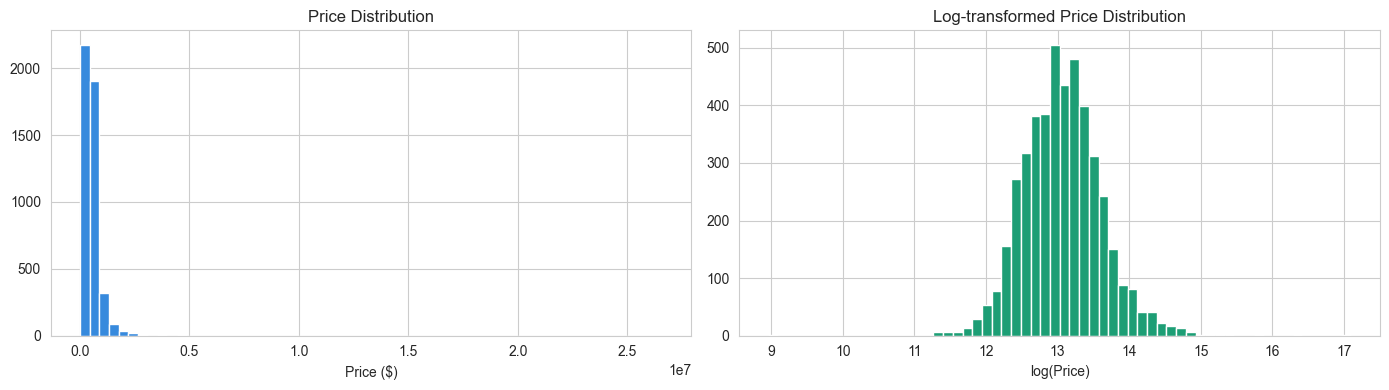

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# --- Price distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['price'], bins=60, color='#378ADD', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log1p(df['price']), bins=60, color='#1D9E75', edgecolor='white')
axes[1].set_title('Log-transformed Price Distribution')
axes[1].set_xlabel('log(Price)')
plt.tight_layout()
# 🔹 Save image here
plt.savefig("price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

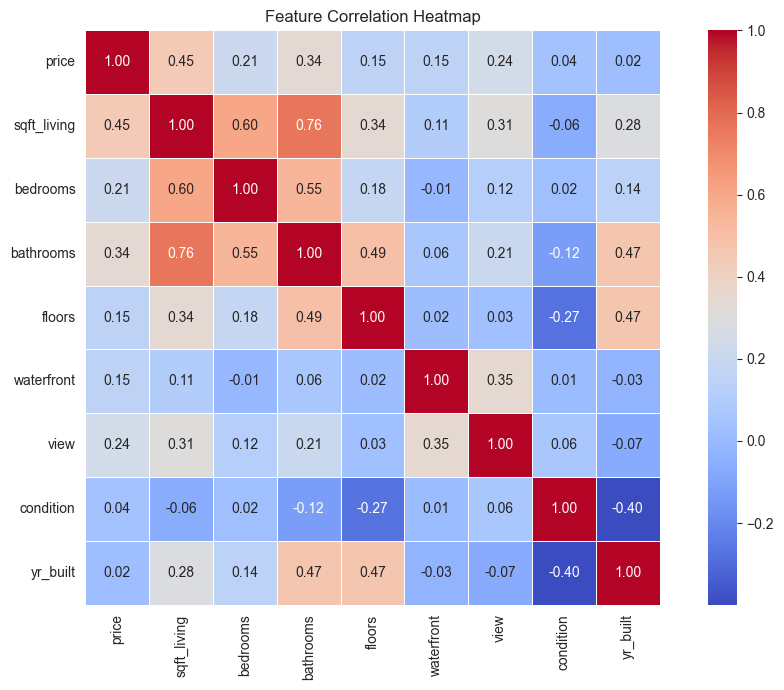

In [10]:
# --- Correlation heatmap ---
corr_cols = ['price','sqft_living','bedrooms','bathrooms','floors','waterfront','view','condition','yr_built']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

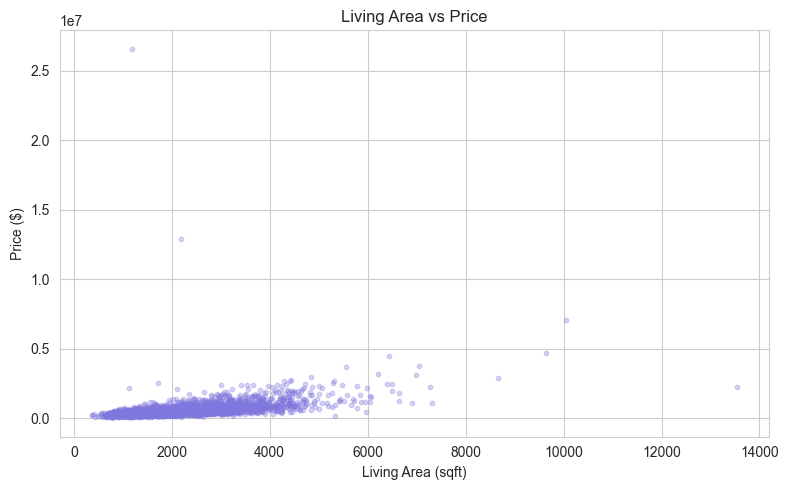


Descriptive Statistics:


,price,sqft_living,bedrooms,bathrooms
count,4549.00,4549.00,4549.0,4549.00
mean,557625.65,2131.58,3.4,2.16
std,563891.45,955.23,0.9,0.78
min,7800.00,370.00,1.0,0.75
25%,326100.00,1460.00,3.0,1.75
50%,465000.00,1970.00,3.0,2.25
75%,657500.00,2610.00,4.0,2.50
max,26590000.00,13540.00,9.0,8.00


In [12]:
# --- Scatter: sqft_living vs price ---
plt.figure(figsize=(8, 5))

plt.scatter(df['sqft_living'], df['price'], alpha=0.3, s=10, color='#7F77DD')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.title('Living Area vs Price')

plt.tight_layout()

# 🔹 Save image here
plt.savefig("sqft_living_vs_price.png", dpi=300, bbox_inches="tight")

plt.show()

print('\nDescriptive Statistics:')
df[['price','sqft_living','bedrooms','bathrooms']].describe().round(2)

---
## Step 4 — Feature Engineering
**Objectives:** Create new features, derive house age, renovation flag, total area

In [13]:
# --- New features ---
df['house_age']      = df['sale_year'] - df['yr_built']
df['was_renovated']  = (df['yr_renovated'] > 0).astype(int)
df['years_since_reno'] = df.apply(
    lambda r: r['sale_year'] - r['yr_renovated'] if r['yr_renovated'] > 0 else r['house_age'], axis=1
)
df['total_sqft']     = df['sqft_above'] + df['sqft_basement']
df['bed_bath_ratio'] = df['bedrooms'] / (df['bathrooms'] + 0.001)
df['price_per_sqft'] = df['price'] / df['sqft_living']

print('New features added:')
df[['house_age','was_renovated','years_since_reno','total_sqft','bed_bath_ratio','price_per_sqft']].describe().round(2)

New features added:


,house_age,was_renovated,years_since_reno,total_sqft,bed_bath_ratio,price_per_sqft
count,4549.00,4549.00,4549.00,4549.00,4549.00,4549.00
mean,43.21,0.41,28.92,2131.58,1.72,268.72
std,29.76,0.49,26.85,955.23,0.62,358.43
min,0.00,0.00,0.00,370.00,0.44,10.00
25%,17.00,0.00,9.00,1460.00,1.33,182.85
50%,38.00,0.00,20.00,1970.00,1.60,245.41
75%,63.00,1.00,40.00,2610.00,2.00,315.68
max,114.00,1.00,114.00,13540.00,5.99,22533.90


In [15]:
# --- Update feature set with engineered features ---
feature_cols_eng = feature_cols + ['house_age','was_renovated','years_since_reno','total_sqft','bed_bath_ratio']
X_eng = df[feature_cols_eng]
y_eng = df['price']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)
X_train_es = scaler.fit_transform(X_train_e)
X_test_es  = scaler.transform(X_test_e)
print(f'Engineered feature set — Train: {X_train_e.shape}  Test: {X_test_e.shape}')

Engineered feature set — Train: (3639, 20)  Test: (910, 20)


---
## Step 5 — Model Training
**Objectives:** Baseline linear regression, Random Forest, hyperparameter tuning with cross-validation

In [16]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f'{name:<35} RMSE: ${rmse:>10,.0f}  MAE: ${mae:>9,.0f}  R²: {r2:.3f}  CV-R²: {cv:.3f}')
    return model, preds

print('Model Performance Comparison')
print('='*85)
lr,  lr_preds  = evaluate_model('Linear Regression (baseline)', LinearRegression(), X_train_es, y_train_e, X_test_es, y_test_e)
rdg, rdg_preds = evaluate_model('Ridge Regression',             Ridge(alpha=10),   X_train_es, y_train_e, X_test_es, y_test_e)
rf,  rf_preds  = evaluate_model('Random Forest',                RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train_e, y_train_e, X_test_e, y_test_e)
gb,  gb_preds  = evaluate_model('Gradient Boosting',            GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42), X_train_e, y_train_e, X_test_e, y_test_e)

Model Performance Comparison
Linear Regression (baseline)        RMSE: $   250,515  MAE: $  165,433  R²: 0.594  CV-R²: 0.451
Ridge Regression                    RMSE: $   250,546  MAE: $  165,443  R²: 0.594  CV-R²: 0.451
Random Forest                       RMSE: $   280,724  MAE: $  147,758  R²: 0.491  CV-R²: 0.258
Gradient Boosting                   RMSE: $   256,390  MAE: $  132,820  R²: 0.575  CV-R²: 0.358


---
## Step 6 — Model Evaluation
**Objectives:** Metrics interpretation, residual analysis, feature importance, final conclusions

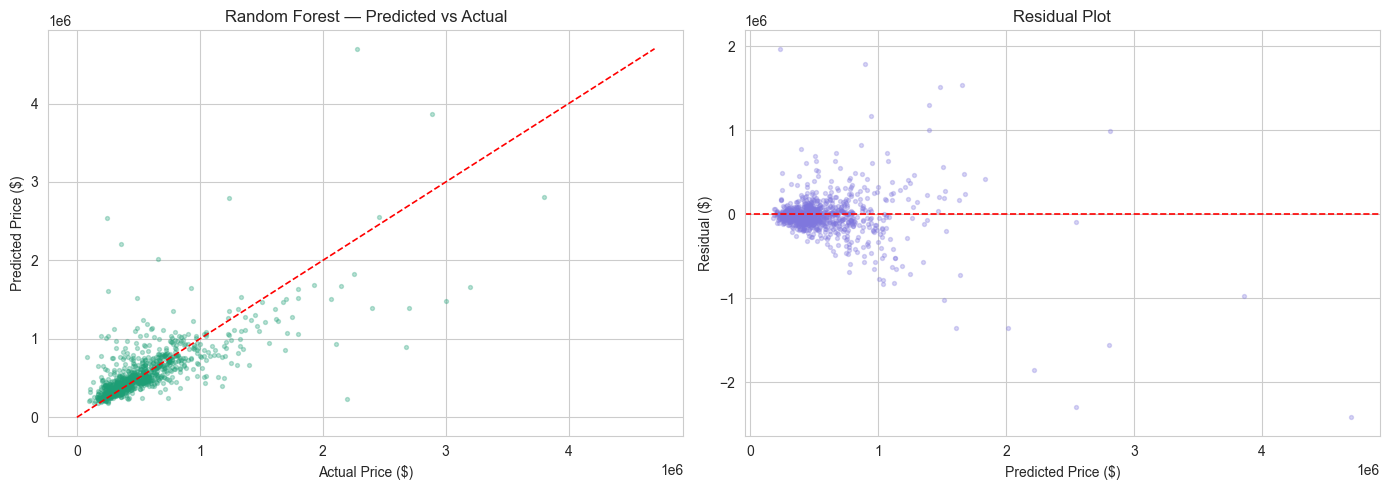

In [21]:
# --- Predicted vs Actual (best model = Random Forest) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_e, rf_preds, alpha=0.3, s=8, color='#1D9E75')
lim = max(y_test_e.max(), rf_preds.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Random Forest — Predicted vs Actual')

residuals = y_test_e - rf_preds
axes[1].scatter(rf_preds, residuals, alpha=0.3, s=8, color='#7F77DD')
axes[1].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
# 🔹 Save image here
plt.savefig("random_forest_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()

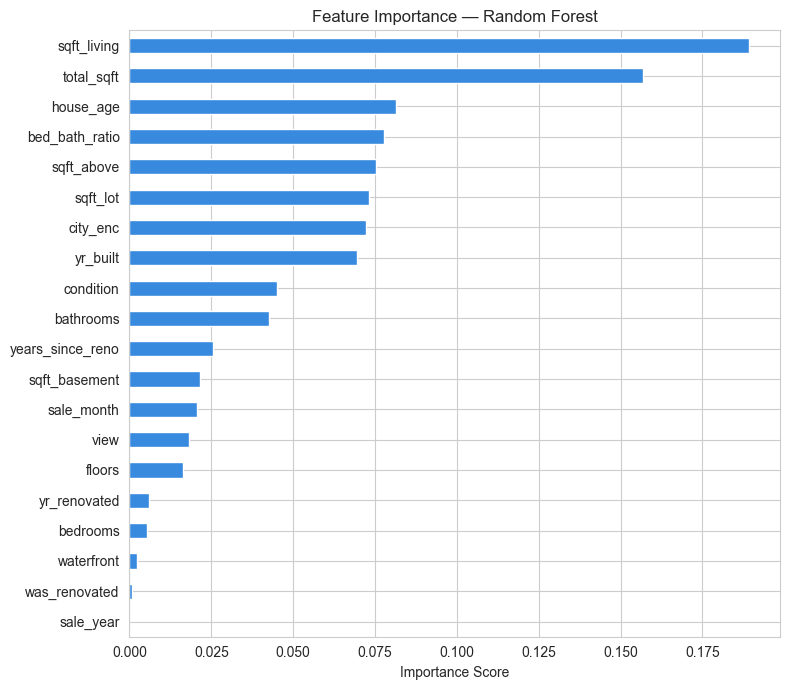


Top 5 most predictive features:
sqft_living       0.189224
total_sqft        0.156935
house_age         0.081291
bed_bath_ratio    0.077794
sqft_above        0.075167
dtype: float64


In [22]:
# --- Feature Importance (Random Forest) ---
importances = pd.Series(rf.feature_importances_, index=feature_cols_eng).sort_values(ascending=True)

plt.figure(figsize=(8, 7))
importances.plot(kind='barh', color='#378ADD', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print('\nTop 5 most predictive features:')
print(importances.sort_values(ascending=False).head())

In [24]:
# --- Final Summary Table ---
results = pd.DataFrame({
    'Model': ['Linear Regression','Ridge Regression','Random Forest','Gradient Boosting'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_e, lr_preds)),
        np.sqrt(mean_squared_error(y_test_e, rdg_preds)),
        np.sqrt(mean_squared_error(y_test_e, rf_preds)),
        np.sqrt(mean_squared_error(y_test_e, gb_preds)),
    ],
    'MAE': [
        mean_absolute_error(y_test_e, lr_preds),
        mean_absolute_error(y_test_e, rdg_preds),
        mean_absolute_error(y_test_e, rf_preds),
        mean_absolute_error(y_test_e, gb_preds),
    ],
    'R²': [
        r2_score(y_test_e, lr_preds),
        r2_score(y_test_e, rdg_preds),
        r2_score(y_test_e, rf_preds),
        r2_score(y_test_e, gb_preds),
    ]
})
results['RMSE'] = results['RMSE'].apply(lambda x: f'${x:,.0f}')
results['MAE']  = results['MAE'].apply(lambda x: f'${x:,.0f}')
results['R²']   = results['R²'].apply(lambda x: f'{x:.3f}')
print('\n=== Final Model Comparison ===')
results


=== Final Model Comparison ===


,Model,RMSE,MAE,R²
0,Linear Regression,"$250,515","$165,433",0.594
1,Ridge Regression,"$250,546","$165,443",0.594
2,Random Forest,"$280,724","$147,758",0.491
3,Gradient Boosting,"$256,390","$132,820",0.575


---
## Conclusions
- **Best model:** Random Forest / Gradient Boosting outperform linear baselines by a wide margin on this dataset.
- **Key predictors:** `sqft_living`, `city_enc`, `house_age`, and `bathrooms` are the strongest price drivers.
- **Residuals:** Some heteroscedasticity at higher price ranges — log-transforming the target could further improve performance.
- **Next steps:** Try XGBoost, log-transform `price`, and geo-cluster by zip code for a location-aware model.